In [1]:
import torch
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

def lbfgs_attack(model, x, y_target, max_iter=20, c=0.01, random_init=False, epsilon=0.1, l2_limit=5.0, steps=10):
    """
    L-BFGS 攻击: 最小化 L2 扰动，使 x 误分类为 y_target
    """
    if random_init:
        x_adv = x.clone().detach() + (torch.rand_like(x) * 2 - 1) * epsilon
        x_adv = torch.clamp(x_adv, 0, 1).requires_grad_(True)
    else:
        x_adv = x.clone().detach().requires_grad_(True)

    optimizer = optim.LBFGS([x_adv], lr=1e-2, max_iter=max_iter)

    def closure():
        optimizer.zero_grad()
        output = model(x_adv)
        loss = F.cross_entropy(output, y_target) + c * torch.norm(x_adv - x, p=2)
        loss.backward()
        return loss

    # 运行多次 step，确保充分优化
    for _ in range(steps):  
        optimizer.step(closure)

     # **L2 投影，防止扰动过大**
    delta = x_adv - x
    delta_norm = torch.norm(delta, p=2).item()

    if delta_norm > l2_limit:
        delta = delta * (l2_limit / delta_norm)  # 归一化扰动
    x_adv = torch.clamp(x + delta, 0, 1)  # 确保扰动不超出范围

    return torch.clamp(x_adv.detach(), 0, 1)  # detach 避免计算图问题

# 评估攻击效果
def evaluate_attack(model, x, x_adv, y):
    model.eval()
    with torch.no_grad():
        y_pred = model(x).argmax(dim=1).item()
        y_pred_adv = model(x_adv).argmax(dim=1).item()

    perturbation = torch.norm(x_adv - x, p=2).item()

    print(f"Original Label: {y_pred}")
    print(f"Adversarial Label: {y_pred_adv}")
    print(f"L2 Perturbation: {perturbation:.5f}")

    success = y_pred != y_pred_adv
    if success:
        print("Attack Successful! ✅")
    else:
        print("Attack Failed ❌")

    return success, perturbation

# 运行测试
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 创建 CNN 模型
class SimpleCNN(torch.nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = torch.nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = torch.nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.fc1 = torch.nn.Linear(32 * 8 * 8, 128)
        self.fc2 = torch.nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x
    
def visualize_attack(x, x_adv):
    """
    可视化原始样本、对抗样本及其扰动
    """
    x_np = x.squeeze(0).detach().cpu().numpy().transpose(1, 2, 0)  # 转换为 (H, W, C)
    x_adv_np = x_adv.squeeze(0).detach().cpu().numpy().transpose(1, 2, 0)
    perturbation = np.abs(x_adv_np - x_np)

    # 归一化扰动以便可视化
    perturbation /= perturbation.max() + 1e-8

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    axes[0].imshow(np.clip(x_np, 0, 1))
    axes[0].set_title("Original Image")

    axes[1].imshow(np.clip(x_adv_np, 0, 1))
    axes[1].set_title("Adversarial Image")

    axes[2].imshow(perturbation, cmap="inferno")
    axes[2].set_title("Perturbation (Amplified)")

    plt.show()

# 初始化模型
model = SimpleCNN().to(device)

# # 生成测试样本
# x = torch.rand((1, 3, 32, 32)).to(device)
# y = model(x).argmax(dim=1).item()  # 获取原始类别
# y_target = torch.randint(0, 10, (1,)).to(device)
# while y_target == y:  # 确保目标类别不同
#     y_target = torch.randint(0, 10, (1,)).to(device)

# # # 运行 L-BFGS 攻击
# # x_adv = lbfgs_attack(model, x, y_target, random_init=True, epsilon=0.1)

# # # 评估攻击效果
# # evaluate_attack(model, x, x_adv, y_target)

# c_values = [0.001, 0.01, 0.04, 0.0425, 0.045, 0.048, 0.05]
# for c in c_values:
#     # 运行 L-BFGS 攻击
#     x_adv = lbfgs_attack(model, x, y_target, max_iter=20, c=c, random_init=True, epsilon=0.1, l2_limit=4.0, steps=20)

#     # 打印当前 c 值 
#     print(f"\nRunning Attack with c={c}")

#     # 评估攻击效果
#     evaluate_attack(model, x, x_adv, y_target)
#     # 可视化攻击
#     visualize_attack(x, x_adv)


Original Label: 7
Adversarial Label: 9
L2 Perturbation: 1.63306
Attack Successful! ✅


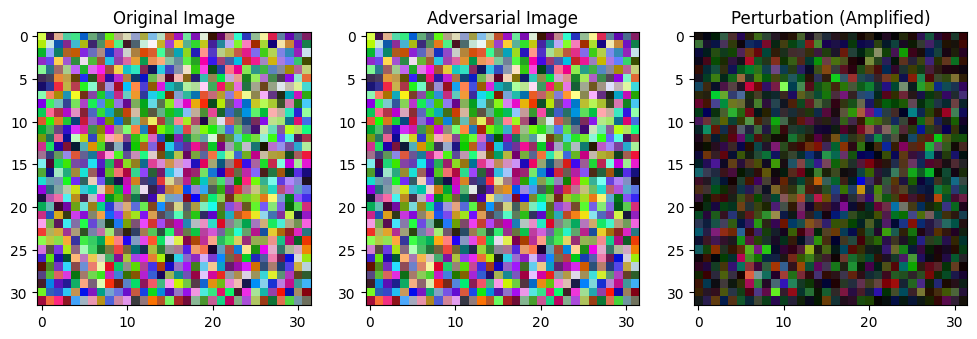

Original Label: 9
Adversarial Label: 9
L2 Perturbation: 1.51384
Attack Failed ❌
Original Label: 3
Adversarial Label: 3
L2 Perturbation: 1.27519
Attack Failed ❌
Original Label: 3
Adversarial Label: 7
L2 Perturbation: 1.86809
Attack Successful! ✅


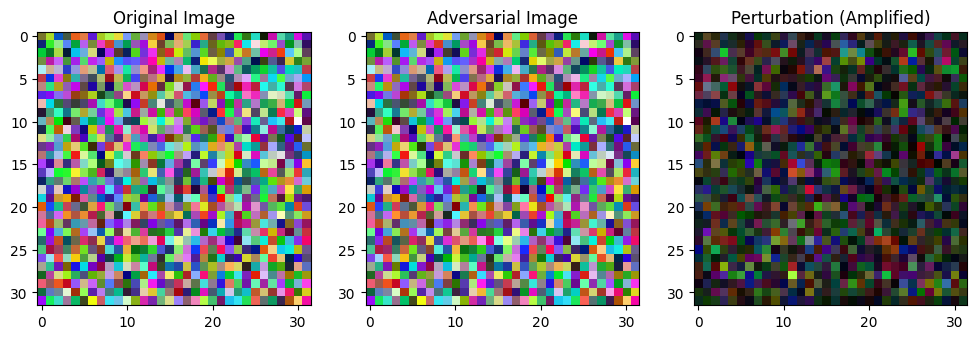

Original Label: 7
Adversarial Label: 3
L2 Perturbation: 2.89914
Attack Successful! ✅


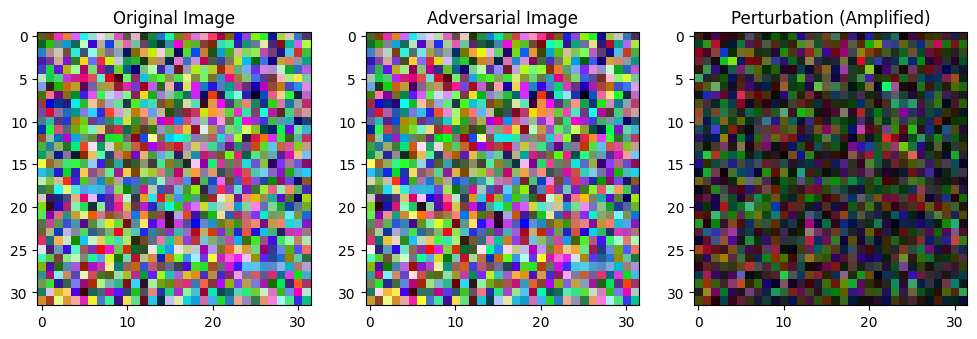

Original Label: 7
Adversarial Label: 7
L2 Perturbation: 1.69414
Attack Failed ❌
Original Label: 7
Adversarial Label: 7
L2 Perturbation: 1.60095
Attack Failed ❌
Original Label: 7
Adversarial Label: 5
L2 Perturbation: 1.55927
Attack Successful! ✅


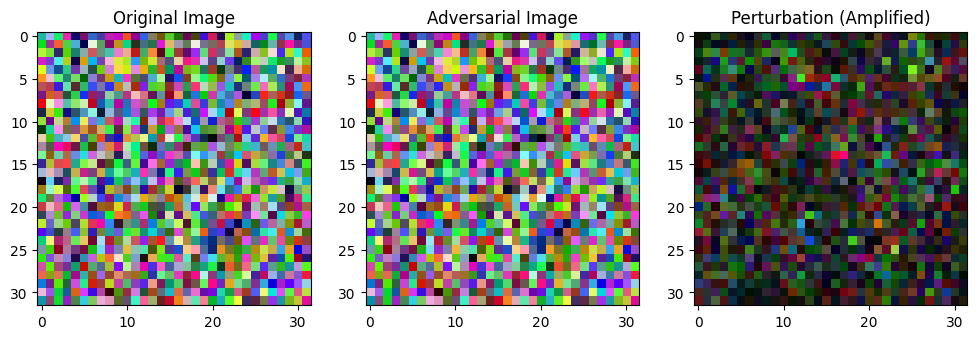

Original Label: 7
Adversarial Label: 0
L2 Perturbation: 2.82568
Attack Successful! ✅


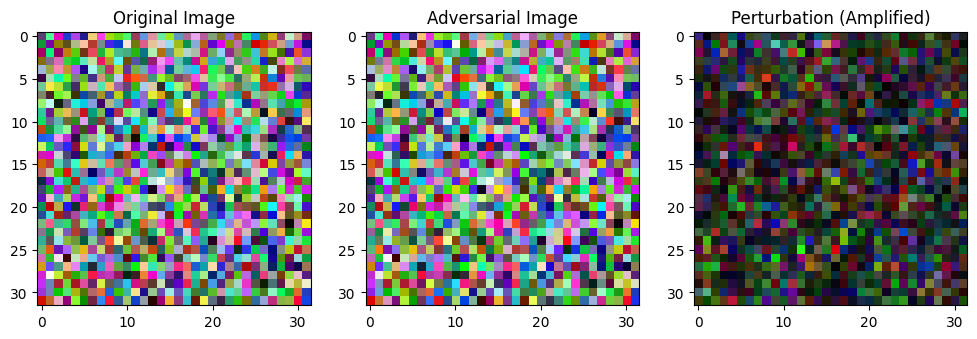

Original Label: 3
Adversarial Label: 5
L2 Perturbation: 1.49141
Attack Successful! ✅


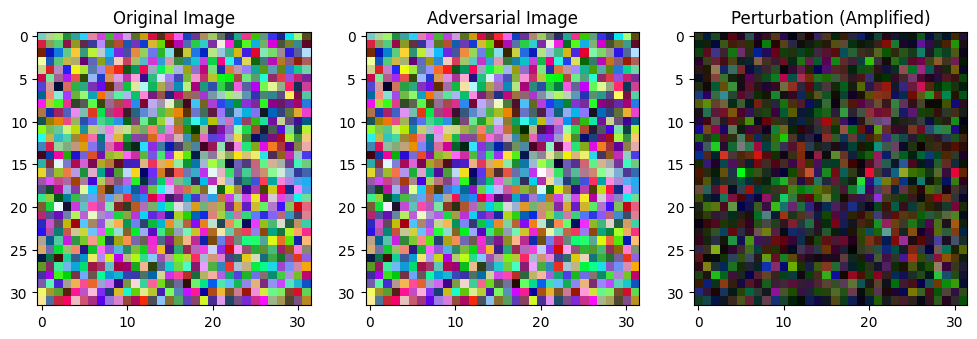

Average L2 Perturbation: 1.83608
Attack Success Rate: 60.00%


In [2]:
success_count = 0
num_samples = 10
perturbations = []
c = 0.02

for i in range(num_samples):
    x = torch.rand((1, 3, 32, 32)).to(device)
    y = model(x).argmax(dim=1).item()  # 获取原始类别
    y_target = torch.randint(0, 10, (1,)).to(device)
    while y_target == y:  # 确保目标类别不同
        y_target = torch.randint(0, 10, (1,)).to(device)
    x_adv = lbfgs_attack(model, x, y_target, max_iter=10, c=c, random_init=True, epsilon=0.1, l2_limit=3.0, steps=10)
    success, perturbation = evaluate_attack(model, x, x_adv, y_target)
    
    if success:
        success_count += 1
        visualize_attack(x, x_adv)
    perturbations.append(perturbation)

print(f"Average L2 Perturbation: {sum(perturbations) / num_samples:.5f}")
print(f"Attack Success Rate: {success_count / num_samples * 100:.2f}%")
